### Computing the Heat Budget for an Arbitrary Cell in ECCO V4r4

In [5]:
using Revise
using ECCOtour, MeshArrays, 
      MITgcmTools, JLD2, 
      LaTeXStrings
using PythonCall
import PythonPlot as plt

sns = pyimport("seaborn")
include("../src/config_exp.jl");

ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Warning: Replacing docs for `ECCOtour.calc_UV_conv3D! :: Union{Tuple{T}, Tuple{MeshArrays.gcmarray{T, 2, Matrix{T}}, MeshArrays.gcmarray{T, 2, Matrix{T}}, MeshArrays.gcmarray{T, 2, Matrix{T}}}} where T<:Real` in module `ECCOtour`
└ @ Base.Docs docs/Docs.jl:243
    CondaPkg Found dependencies: /home/anthony.meza/repos/ECCOtour.jl/CondaPkg.toml
    CondaPkg Found dependencies: /home/anthony.meza/.julia/packages/PythonCall/S5MOg/CondaPkg.toml
    CondaPkg Found dependencies: /home/anthony.meza/.julia/packages/PythonPlot/lPI7G/CondaPkg.toml
    CondaPkg Dependencies already up to date


#### Load in packages and relevant LLC90 grid information

In [13]:
runpath,diagpath = listexperiments(exprootdir());

tecco = range(1992,step=1/12,stop=2018)
ocean_mask = wet_pts(Γ)
area = readarea(γ);

cell_depths = get_cell_thickness(ocean_mask, ΔzF, Γ.hFacC); 
cell_volumes = get_cell_volumes(area, cell_depths);

H = vertical_sum(cell_depths); H[findall(H .== 0.0)] = Inf
inv_H = 1 ./ H;

Available experiments are
interannual_eqpac
iter129_bulkformula
noinitadjust
nosfcadjust
nointerannual_buoyancy
nointerannual_wind
interannual_southpac
climatological_tau
seasonalclimatology_iter0
add_sigma1_windstresscurl.m
iter0_bulkformula
nointerannual_eqpac
interannual_southpac_cora
checkout_plots.m
iter129_fluxforced
interannual_northpac
nointerannual
compare_timeseries.m


#### Load in $\theta, \eta$. Also load in advective and diffusive heat fluxes

In [30]:
#define experimennt
expname = "iter129_bulkformula"
diagnostic_directory = diagpath[expname] #directory that contains the data
get_data_files(xx, expname) = filter(x -> occursin("data",x),searchdir(diagnostic_directory,xx))

#define the file names
datafilelist_H  = get_data_files("trsp_3d_set2", expname)
datafilelist_R  = get_data_files("trsp_3d_set3", expname)
datafilelist_θ  = get_data_files("state_3d_set1", expname)
datafilelist_S  = get_data_files("state_2d_set1", expname);

In [42]:
#get the geothermal heating term
GTF = get_geothermalheating(Γ, γ)

#specify time-step
tt = 200
dt = tecco[tt + 1] .- tecco[tt]
fnameH = datafilelist_H[tt]
fnameR = datafilelist_R[tt]
fnameθ = datafilelist_θ[tt]
fnameS = datafilelist_S[tt];
fnameθp1 = datafilelist_θ[tt+1]
fnameSp1 = datafilelist_S[tt+1];
fnameHp1 = datafilelist_H[tt+1]
fnameRp1 = datafilelist_R[tt+1]

"trsp_3d_set3.0000146820.data"

In [43]:
#Load in temperature and heat budget terms
sθ = extract_sθ(expname,diagpath, γ, fnameS, fnameθ, inv_H)
sθp1 = extract_sθ(expname,diagpath, γ, fnameS, fnameθp1, inv_H)
dθdt = (sθp1 .- sθ) ./ (dt * 86400 * 365.5)

κUθ, κVθ, Uθ, Vθ = extract_lateral_heatbudget(diagpath, expname , fnameH, γ)
κzθ, wθ = extract_vertical_heatbudget(diagpath, expname , fnameR, γ);

κUθp1, κVθp1, Uθp1, Vθp1 = extract_lateral_heatbudget(diagpath, expname , fnameHp1, γ)
κzθp1, wθp1 = extract_vertical_heatbudget(diagpath, expname , fnameRp1, γ);

#### Compute vertical and horizontal heat convergences

In [44]:
#compute convergences for all ocean gridcells
κθ_conv3D = MeshArray(γ,Float32,50);
κθ_conv3Dp1 = MeshArray(γ,Float32,50);
calc_UV_conv3D!(κUθ, κVθ, κθ_conv3D); #horizontal diffusive converegence
calc_UV_conv3D!(κUθp1, κVθp1, κθ_conv3Dp1); #horizontal diffusive converegence

uθ_conv3D = MeshArray(γ,Float32,50);
uθ_conv3Dp1 = MeshArray(γ,Float32,50);
calc_UV_conv3D!(Uθ, Vθ, uθ_conv3D); #horizontal advective converegence
calc_UV_conv3D!(Uθp1, Vθp1, uθ_conv3Dp1); #horizontal advective converegence

wθ_conv = MeshArray(γ,Float32,50);
wθ_convp1 = MeshArray(γ,Float32,50);
calc_W_conv3D!(wθ, wθ_conv) #vertical diffusive converegence
calc_W_conv3D!(wθp1, wθ_convp1) #vertical diffusive converegence

κzθ_conv = MeshArray(γ,Float32,50);
κzθ_convp1 = MeshArray(γ,Float32,50);
calc_W_conv3D!(κzθ, κzθ_conv) #vertical advective converegence
calc_W_conv3D!(κzθp1, κzθ_convp1) #vertical advective converegence

#### Select arbitrary grid cell and plot an monthly snapshot of the heat budget. Since we are not using daily snapshots of $\eta$ and $\theta$, the RHS and LHS are not guaranteed to balance. 

*It is pretty close sometimes though!*

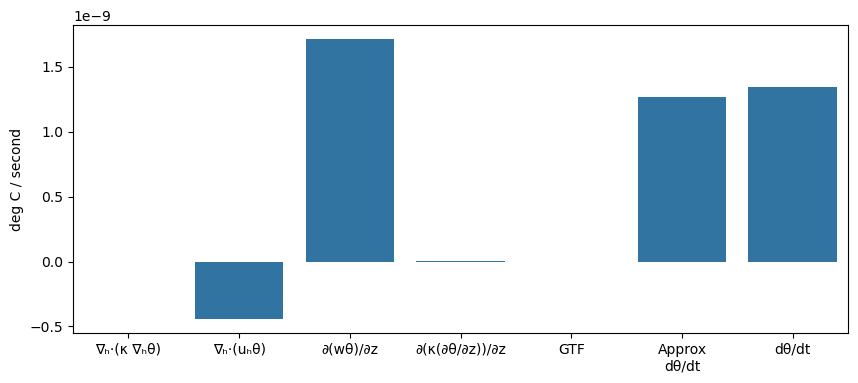

In [45]:
select_cell(x) = x[4, 43][110, 45]

vars = [select_cell(κθ_conv3D .+ κθ_conv3Dp1) ./ 2, 
        select_cell(uθ_conv3D .+ uθ_conv3Dp1) ./ 2, 
        select_cell(wθ_conv .+ wθ_convp1) ./ 2, 
        select_cell(κzθ_conv .+ κzθ_convp1) ./ 2] 

push!(vars, select_cell(GTF))
push!(vars, sum(vars))

vars = vars ./ select_cell(cell_volumes)
push!(vars, select_cell(dθdt))

labels = ["∇ₕ⋅(κ ∇ₕθ)", "-∇ₕ⋅(uₕθ)", "∂(wθ)/∂z", "∂(κ(∂θ/∂z))/∂z", "GTF", "Approx\ndθ/dt", "dθ/dt"]

fig, ax = plt.subplots(figsize = (10, 4))
sns.barplot(x=labels, y=vars, ax = ax)
ax.set_ylabel("deg C / second")
fig